In [1]:
print('hi')

hi


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

# os.getenv("GROQ_API_KEY")

True

In [3]:
model="openai/gpt-oss-120b"

In [4]:
from langchain_groq import ChatGroq

In [5]:
llm=ChatGroq(model=model,
                temperature=0.5,
                api_key=os.getenv("GROQ_API_KEY"))

In [6]:
from langchain.tools import tool

In [7]:
## All the below tools are the custom tools
@tool
def multiply(a:int, b:int)->int:
    """
    Multiply two integers.
    
    Args:
        a: The first integer.
        b: The second integer.
        
    Returns:
        The product of a and b.
    """
    return a * b

@tool
def add(a:int, b:int)->int:
    """
    Add two integers.
    
    Args:
        a: The first integer.
        b: The second integer.
        
    Returns:
        The sum of a and b.
    """
    return a+b

@tool
def divide(a:int, b:int)->float:
    """
    Divide two integers.
    
    Args:
        a: The first integer.
        b: The second integer.
        
    Returns:
        float: The resulllt of the division.
    """
    if b==0:
        raise ValueError("Cannot divide by zero")
    return a/b


In [8]:
## Importing the in-built tools

from langchain_community.tools import DuckDuckGoSearchRun

search=DuckDuckGoSearchRun()

In [9]:
# testing the ddgs tool
search.invoke("What is the capital of India?")

'... is a list of locations which have served as the ... The current capital city of the Indian Republic is New Delhi , which replaced Calcutta in 1911. For example, Delhi is the national capital of India, while Mumbai is ... New Delhi is the capital of India, established during British rule in 1911. What is the Capital of India? ... The capital city or the National Capital Territory (NCT) of India is New Delhi. ... What Is The Capital Of The ... What is the capital of India? ... What is the purpose of " seeding " a cloud? ... What 1980’s and 1990’s law drama was set at the firm ... New Delhi , the capital city of India , is one of the most important and historically significant cities in the country.'

In [10]:
tools=[multiply, add, divide, search]

In [11]:
llm_with_tools=llm.bind_tools(tools)

In [12]:
response=llm_with_tools.invoke("hi")

In [13]:
response.content

'Hello! How can I help you today?'

In [14]:
response.tool_calls

[]

In [15]:
response2=llm_with_tools.invoke("What is 200+290?")

In [16]:
response2

AIMessage(content='200\u202f+\u202f290\u202f=\u202f490.', additional_kwargs={'reasoning_content': 'User asks simple addition. We can compute directly: 200+290=490. No need for function.'}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 314, 'total_tokens': 356, 'completion_time': 0.111748207, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.003587163, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.052241806, 'total_time': 0.11533537}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da9bb-a9c6-7671-a2c9-6a2354510c34-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 314, 'output_tokens': 42, 'total_tokens': 356, 'input_token_details': {'cache_read': 256}, 'output_token_details': {'reasoning': 23}})

In [17]:
response2.tool_calls

[]

In [18]:
response3=llm_with_tools.invoke("What is 200/290?")
print(response3)
print(response3.tool_calls)

content='' additional_kwargs={'reasoning_content': 'User asks: "What is 200/290?" That\'s division. Use divide function.', 'tool_calls': [{'id': 'fc_dfaf1748-32ad-4f4e-ae8d-3ac11ef4f31d', 'function': {'arguments': '{"a":200,"b":290}', 'name': 'divide'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 314, 'total_tokens': 366, 'completion_time': 0.109918178, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.056419958, 'prompt_tokens_details': None, 'queue_time': 0.084461078, 'total_time': 0.166338136}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019da9bb-aaee-7023-9e1e-60e6f1b5bdcf-0' tool_calls=[{'name': 'divide', 'args': {'a': 200, 'b': 290}, 'id': 'fc_dfaf1748-32ad-4f4e-ae8d-3ac11ef4f31d', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 31

In [19]:
response4=llm_with_tools.invoke("What is the population of India?")

In [20]:
response4.content

''

In [21]:
response4.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'current population of India 2024'},
  'id': 'fc_19a2e241-9d92-44ac-aed7-bea2dc3c3569',
  'type': 'tool_call'}]

In [22]:
print(response4)

content='' additional_kwargs={'reasoning_content': 'User asks: "What is the population of India?" Need current data. Likely need up-to-date info, so use search. Use duckduckgo_search.', 'tool_calls': [{'id': 'fc_19a2e241-9d92-44ac-aed7-bea2dc3c3569', 'function': {'arguments': '{"query":"current population of India 2024"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 314, 'total_tokens': 384, 'completion_time': 0.151090068, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.841970983, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.051389355, 'total_time': 0.993061051}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019da9bb-ac10-7b81-809c-2a34ac8d5bc1-0' tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'current 

In [23]:
from pydantic import BaseModel, Field
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import operator
from typing import List, TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

In [24]:
SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on set of inputs."

In [25]:
def function_1(state: MessagesState):
    user_question=state['messages']
    input_question=[SYSTEM_PROMPT]+user_question
    response=llm_with_tools.invoke(input_question)
    return {"messages": [response]}

In [26]:
builder=StateGraph(MessagesState)

In [27]:
builder.add_node("llm_decision_step", function_1)

In [28]:
builder.add_node("tools", ToolNode(tools))

In [29]:
builder.add_edge(START, "llm_decision_step")

In [30]:
## tools_condition is the in-built router function

builder.add_conditional_edges("llm_decision_step", tools_condition)

In [31]:
builder.add_edge("tools", "llm_decision_step")

In [32]:
react_graph=builder.compile()

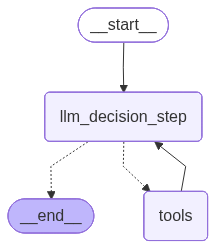

In [33]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [34]:
message=HumanMessage(content="What is the 2 times of the age of Narendra Modi?")

In [35]:
result=react_graph.invoke({"messages": message})

In [36]:
result

{'messages': [HumanMessage(content='What is the 2 times of the age of Narendra Modi?', additional_kwargs={}, response_metadata={}, id='e8388630-800e-4852-b83a-cdc27b91f602'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to find Narendra Modi's age, then multiply by 2. Need to search for his age (current). Use duckduckgo_search.", 'tool_calls': [{'id': 'fc_c75c5d48-1efd-4568-b5ac-289f99674f03', 'function': {'arguments': '{"query":"Narendra Modi age"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 341, 'total_tokens': 405, 'completion_time': 0.133599007, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.020258596, 'prompt_tokens_details': None, 'queue_time': 0.157601174, 'total_time': 0.153857603}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_974392087a', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'mode

In [37]:
result['messages'][-1].content

'Narendra\u202fModi was born on **17\u202fSeptember\u202f1950**.  \nAs of today (20\u202fApril\u202f2026) his age is:\n\n- **75\u202fyears**\n- **7\u202fmonths**\n- **3\u202fdays**\n\n---\n\n### Twice that age\n\n| Unit | Calculation | Result |\n|------|-------------|--------|\n| Years | 2\u202f×\u202f75\u202f=\u202f150 | 150\u202fyears |\n| Months | 2\u202f×\u202f7\u202f=\u202f14\u202fmonths → 1\u202fyear\u202f2\u202fmonths | +1\u202fyear\u202f2\u202fmonths |\n| Days | 2\u202f×\u202f3\u202f=\u202f6\u202fdays | +6\u202fdays |\n\n**Combined:**  \n**151\u202fyears,\u202f2\u202fmonths,\u202f6\u202fdays**\n\nIf you prefer a single‑number approximation in years:\n\n- Age in years ≈\u202f75\u202f+\u202f7/12\u202f+\u202f3/365\u202f≈\u202f75.59\u202fyears  \n- Twice that ≈\u202f151.18\u202fyears (about **151\u202fyears and 2\u202fmonths**).\n\nSo, twice Narendra\u202fModi’s current age is roughly **151\u202fyears,\u202f2\u202fmonths,\u202f6\u202fdays** (≈\u202f151.2\u202fyears).'

In [38]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the 2 times of the age of Narendra Modi?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_c75c5d48-1efd-4568-b5ac-289f99674f03)
 Call ID: fc_c75c5d48-1efd-4568-b5ac-289f99674f03
  Args:
    query: Narendra Modi age
================================= Tool Message =================================
Name: duckduckgo_search

Narendra Modi Height, Age, Caste, Wife, Family, Biography ... Narendra Modi was engaged to Jashodaben at a very young age. Narendra Modi Age, Birthday Facts and Birthday Countdown ... 74 years, 9months, 14 days old age Narendra Modi will turn 75 on 17 September, 2025. Home » Politician » Narendra Modi Height, Weight, Age, Wife, Biography, Family & Affairs ... Narendra Modi (born 17 September 1950 ... Home - Actor - Narendra Modi Age, Height, Weight, Wiki, Biography, Family and More ... we will explore details about 

In [39]:
message=HumanMessage(content="What is the net worth of Elon musk, divide that by 2?")

In [40]:
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content='What is the net worth of Elon musk, divide that by 2?', additional_kwargs={}, response_metadata={}, id='44892085-0136-48da-a11d-55df1cd986ec'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: net worth of Elon Musk, then divide by 2. Must use search to get current net worth. Use duckduckgo_search. Then parse result, likely a number. Then divide by 2 using function. We\'ll need to extract numeric value. Might need to handle formatting like "$190\u202fbillion". We\'ll need to convert to number. Could approximate. Let\'s search.', 'tool_calls': [{'id': 'fc_083f9c6f-3ec1-4f7b-82d8-bebd1ae90097', 'function': {'arguments': '{"query":"Elon Musk net worth 2024"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 343, 'total_tokens': 461, 'completion_time': 0.247528914, 'completion_tokens_details': {'reasoning_tokens': 81}, 'prompt_time': 0.24

In [41]:
message=HumanMessage(content="What is the speed of light, multiply that by 2?")
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content='What is the speed of light, multiply that by 2?', additional_kwargs={}, response_metadata={}, id='3b209134-54d7-40b0-9ed6-1da08ea2d394'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to answer: speed of light, multiply by 2. Need to get speed of light value. Likely known constant: 299,792,458 meters per second. Multiply by 2 = 599,584,916 m/s. Could also be in km/s: 299,792 km/s approx. Multiply by 2 = 599,584 km/s. Provide answer. No need to search? Could use known constant. But maybe verify via search. Let's do a search to be safe.", 'tool_calls': [{'id': 'fc_a78617fd-b20d-4c2f-b358-10153e05dacd', 'function': {'arguments': '{"query":"speed of light in meters per second"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 341, 'total_tokens': 483, 'completion_time': 0.46645695, 'completion_tokens_details': {'reasoning_tokens': 106}, 'prompt_

In [42]:
import yfinance as yf


In [43]:
@tool
def get_stock_price(ticker: str) -> str:
    """
    Fetches the previous closing price of the given stock ticker from Yahoo finance.

    Args:
        ticker: The stock ticker symbol of the stock to fetch the price for (e.g., 'AAPL', 'GOOG', 'TSLA').

    Returns:
        str: A message with the previous closing price of the stock.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get("previousClose")
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"Error fetching data for {ticker}: {str(e)}"

In [44]:
# get_stock_price("AAPL")
get_stock_price.invoke({"ticker": "AAPL"})

'The last closing price of AAPL was $263.40.'

In [45]:
get_stock_price.invoke({"ticker": "TSLA"})


'The last closing price of TSLA was $388.90.'

In [65]:
tools=[add, multiply, divide, get_stock_price, search]

In [66]:
llm_with_tools=llm.bind_tools(tools)

In [48]:
response=llm_with_tools.invoke("What is the stock price of Adani greens?")

In [49]:
response.content


''

In [50]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'ADANIGREEN.NS'},
  'id': 'fc_d4c326b2-cbc2-41bc-9ec0-9ba91184de96',
  'type': 'tool_call'}]

In [51]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the stock price of Adani greens?" Likely they refer to "Adani Green Energy Ltd" ticker maybe "ADANIGREEN" on Indian stock exchange. The function get_stock_price expects ticker symbol like \'AAPL\', etc. We need to fetch price. We need to know ticker. For Indian stocks, ticker might be "ADANIGREEN.NS" for NSE. The function likely expects just the ticker string. We can try "ADANIGREEN.NS". Let\'s call get_stock_price with ticker "ADANIGREEN.NS".', 'tool_calls': [{'id': 'fc_d4c326b2-cbc2-41bc-9ec0-9ba91184de96', 'function': {'arguments': '{"ticker":"ADANIGREEN.NS"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 352, 'total_tokens': 506, 'completion_time': 0.320706341, 'completion_tokens_details': {'reasoning_tokens': 121}, 'prompt_time': 0.024253243, 'prompt_tokens_details': None, 'queue_time': 0.164816112, 'total_time':

In [52]:
SYSTEM_PROMPT=SystemMessage("You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on set of inputs.")
def function_1(state: MessagesState):
    user_question=state['messages']
    input_question=[SYSTEM_PROMPT]+user_question
    response=llm_with_tools.invoke(input_question)
    return {"messages": [response]}

In [53]:
workflow=StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges("llm_decision_step", tools_condition)
workflow.add_edge("tools", "llm_decision_step")
react_graph2=workflow.compile()

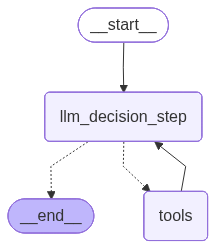

In [54]:
display(Image(react_graph2.get_graph().draw_mermaid_png()))

In [60]:
message=HumanMessage(content="Add 1000 to the current price of Apple")
result2=react_graph2.invoke({"messages": message})

In [61]:
for m in result2['messages']:
    m.pretty_print()


================================ Human Message =================================

Add 1000 to the current price of Apple
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (fc_93b6ed30-e5ba-4b39-a85b-04212930d1ec)
 Call ID: fc_93b6ed30-e5ba-4b39-a85b-04212930d1ec
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $263.40.
================================== Ai Message ==================================

The previous closing price of Apple (AAPL) was **$263.40**. Adding $1,000 to that gives:

**$263.40 + $1,000 = $1,263.40**.


In [73]:
message=HumanMessage(content="Add 1000 to the current price of Apple with the latest news of Apple")
result3=react_graph2.invoke({"messages": message})

In [74]:
for m in result3['messages']:
    m.pretty_print()


================================ Human Message =================================

Add 1000 to the current price of Apple with the latest news of Apple
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (fc_5c6ece9a-0c8f-41cd-a9bf-685c104eb51e)
 Call ID: fc_5c6ece9a-0c8f-41cd-a9bf-685c104eb51e
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $263.40.
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_cee597ca-e596-4a07-abdf-3a05a3b28e4f)
 Call ID: fc_cee597ca-e596-4a07-abdf-3a05a3b28e4f
  Args:
    query: latest news Apple
================================= Tool Message =================================
Name: duckduckgo_search

Error: duckduckgo_search is not a valid tool, try one of [add, multiply, divide, get_stock_price].
==========================

Assignment 5: AI travel Agent& Expense Planner (Purpose: Trip Planning for  for any city worldwide)

- Real time weather information
- top attractions and activities
- Hotel cost calculation (per day * total no. of days)
- Currency conversion to user's relative currency
- Complete itinerary generation
- Total expenses calculation
- Generate a summary of the entire o/p